In [ ]:
import torch
from torch import nn
from torch.nn import functional as F

from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision.datasets import MNIST

from matplotlib import pyplot as plt

from torch import optim
import numpy as np

In [ ]:
BATCH_SIZE = 64
NUM_EPOCHS = 3

In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Using {device} device")

Using cpu device


In [ ]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
train_validation_data = MNIST('.', train=True, transform=transform, download=True)
test_data = MNIST('.', train=False, transform=transform, download=True)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 10.5MB/s]


Extracting ./MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.26MB/s]


Extracting ./MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 9.18MB/s]


Extracting ./MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 4.91MB/s]


Extracting ./MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST/raw



In [ ]:
train_validation_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: .
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.5], std=[0.5])
           )

In [ ]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: .
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.5], std=[0.5])
           )

In [ ]:
train_data, validation_data = random_split(train_validation_data, [50000, 10000])

In [ ]:
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
validation_dataloader = DataLoader(dataset=validation_data, batch_size=BATCH_SIZE, shuffle = False, drop_last=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

In [ ]:
X, y = next(iter(train_dataloader))

In [ ]:
X.shape, X.dtype


(torch.Size([64, 1, 28, 28]), torch.float32)

In [ ]:
y.shape, y.dtype

(torch.Size([64]), torch.int64)

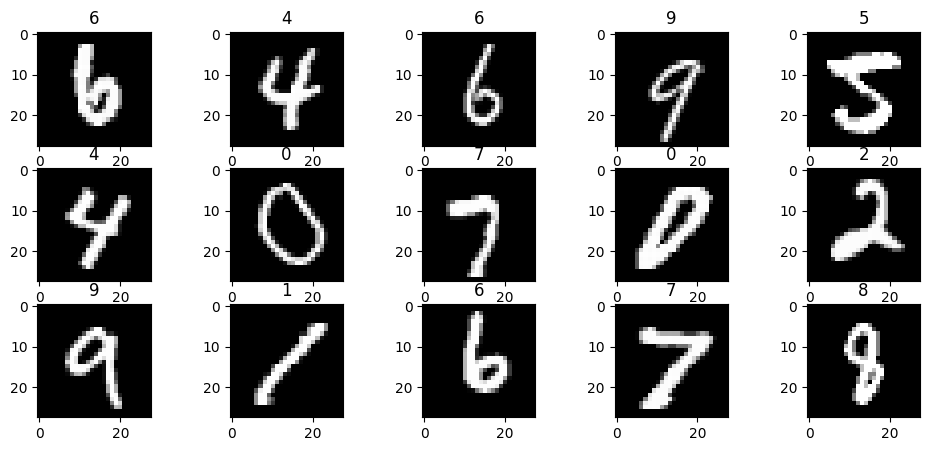

In [ ]:
plt.figure(figsize=(12,5))

for i in range(15):
  x, y = next(iter(train_dataloader))
  plt.subplot(3, 5, i + 1)
  plt.title(f'{y[0]}')
  plt.imshow(x[0].squeeze(), cmap='gray')

plt.show()

In [ ]:
model = None

In [ ]:
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(in_features=64 * 7 * 7, out_features=100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features=100, out_features=10)
        )

    def forward(self, x):
        logits = self.model(x)
        return logits

In [ ]:
model = MyModel().to(device)
model

MyModel(
  (model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=3136, out_features=100, bias=True)
    (10): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout(p=0.5, inplace=False)
    (13): Linear(in_features=100, out_features=10, bias=True)
  )
)

In [ ]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=model.parameters(), lr=1e-3)

In [ ]:
def train_epoch(model, dataloader, loss_function, optimizer, device):

    model.train()
    total_loss = 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()

        pred = model(X)
        loss = loss_function(pred, y)
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    average_loss = total_loss / len(dataloader)
    return average_loss


In [ ]:
def validate_epoch(model, dataloader, loss_function, device):
    """
    Validates the model for one epoch.

    Args:
        model (torch.nn.Module): The neural network model to be validated.
        dataloader (torch.utils.data.DataLoader): The DataLoader containing the validation data.
        loss_function (torch.nn.Module): The loss function used to compute the validation loss.
        device (torch.device): The device (CPU or GPU) on which the model and data are located.

    Returns:
        tuple: A tuple containing:
            - float: The average validation loss for the epoch.
            - float: The accuracy of the model on the validation dataset (in percentage).
    """

    model.eval()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            pred = model(X)
            loss = loss_function(pred, y)
            total_loss += loss.item()

            _, predicted = torch.max(pred, 1)
            correct_predictions += (predicted == y).sum().item()
            total_samples += y.size(0)

    average_loss = total_loss / len(dataloader)
    accuracy = 100 * correct_predictions / total_samples
    return average_loss, accuracy

In [ ]:
def test_model(model, dataloader, loss_function, device):
    return validate_epoch(model, dataloader, loss_function, device)

In [ ]:
from IPython.display import clear_output

def show_losses(train_loss_hist, val_loss_hist):
  clear_output(wait=True)

  plt.figure(figsize=(12, 6))

  plt.subplot(2, 1, 1)
  plt.title('Train and Validation Loss')
  plt.plot(train_loss_hist, label='Train Loss')
  plt.plot(val_loss_hist, label='Validation Loss')
  plt.yscale('log')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.grid()
  plt.legend()

  plt.show()

def show_accuracy(val_acc_hist):
  plt.figure(figsize=(12, 6))

  plt.title('Validation Accuracy')
  plt.plot(val_acc_hist, label='Validation Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy (%)')
  plt.grid()
  plt.legend()

  plt.show()

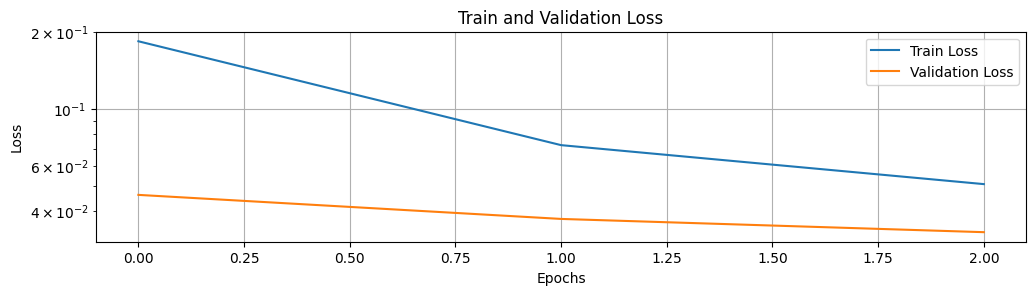

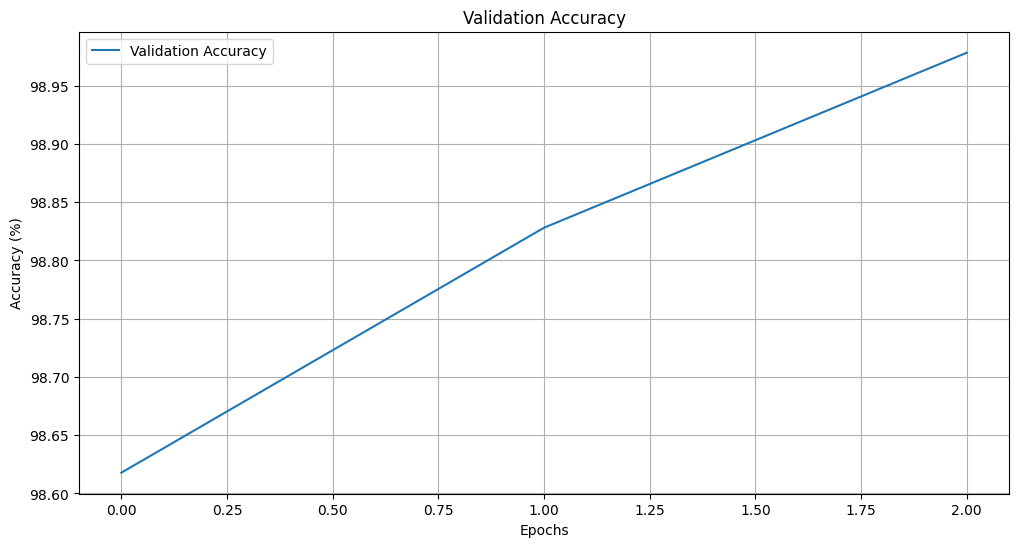

Epoch 3/3
Train Loss: 0.0508
Validation Loss: 0.0330, Validation Accuracy: 98.98%


In [ ]:
train_loss_hist = []
val_loss_hist = []
val_acc_hist = []

for epoch in range(NUM_EPOCHS):
  train_loss= train_epoch(model, dataloader=train_dataloader, loss_function=loss_function, optimizer=optimizer, device=device)
  train_loss_hist.append(train_loss)

  val_loss, val_accuracy = validate_epoch(model, dataloader=validation_dataloader, loss_function=loss_function, device=device)
  val_loss_hist.append(val_loss)
  val_acc_hist.append(val_accuracy)

  show_losses(train_loss_hist, val_loss_hist)
  show_accuracy(val_acc_hist)

  print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
  print(f"Train Loss: {train_loss:.4f}")
  print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")

In [ ]:
test_loss, test_accuracy = test_model(model, dataloader=test_dataloader, loss_function=loss_function, device=device)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.0294, Test Accuracy: 99.05%


----

In [ ]:
import cv2
from google.colab import drive

from scipy.ndimage import center_of_mass

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToPILImage(),
    torchvision.transforms.Resize((28, 28)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
def prepare_contours(image):
  height, width = image.shape[:2]

  default_width = 4624
  default_height = 2080
  default_area = default_width * default_height

  current_area = width * height
  scale_factor = current_area / default_area

  min_num_area = int(15000 * scale_factor)


  hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

  lower_salad = np.array([40, 140, 130])
  upper_salad = np.array([90, 255, 255])
  mask = cv2.inRange(hsv_image, lower_salad, upper_salad)

  kernel = np.ones((5, 5), np.uint8)
  mask_cleaned = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

  contours, _ = cv2.findContours(mask_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_num_area]
  print(f"Количество найденных контуров: {len(contours)}")

  return mask_cleaned, contours

In [ ]:
def get_best_shift(img):
    cy, cx = center_of_mass(img)
    rows, cols = img.shape
    shiftx = np.round(cols / 2.0 - cx).astype(int)
    shifty = np.round(rows / 2.0 - cy).astype(int)
    return shiftx, shifty

def shift_image(img, shiftx, shifty):
    rows, cols = img.shape
    M = np.float32([[1, 0, shiftx], [0, 1, shifty]])
    return cv2.warpAffine(img, M, (cols, rows))

In [ ]:
def contour_to_mnist(mask, contour):
  x, y, w, h = cv2.boundingRect(contour)
  digit_image = mask[y:y + h, x:x + w]
  digit_h, digit_w = digit_image.shape
  scale = min(20 / digit_h, 20 / digit_w)
  new_w, new_h = int(digit_w * scale), int(digit_h * scale)

  resized_digit = cv2.resize(digit_image, (new_w, new_h), interpolation=cv2.INTER_AREA)

  centered_digit = np.zeros((20, 20), dtype=np.uint8)
  start_x = (20 - new_w) // 2
  start_y = (20 - new_h) // 2
  centered_digit[start_y:start_y + new_h, start_x:start_x + new_w] = resized_digit

  rows_padding = (4, 4)
  cols_padding = (4, 4)
  padded_digit = np.pad(centered_digit, (rows_padding, cols_padding), mode='constant', constant_values=0)

  shiftx, shifty = get_best_shift(padded_digit)
  shifted_digit = shift_image(padded_digit, shiftx, shifty)
  #cy, cx = center_of_mass(shifted_digit)
  #print(f"Центр масс: ({cy}, {cx})")
  return shifted_digit

In [ ]:
def predict_label(image):
    predictions = []
    mask, contours = prepare_contours(image)

    for cnt in contours:

        digit_image = contour_to_mnist(mask, cnt)
        digit_image_tensor = transform(digit_image)
        digit_image_tensor = digit_image_tensor.unsqueeze(0)

        rotated_image_tensor = torchvision.transforms.functional.rotate(digit_image_tensor, angle=180)

        with torch.no_grad():
            output_original = model(digit_image_tensor)
            probabilities_original = torch.softmax(output_original, dim=1)
            max_prob_original, predicted_original = probabilities_original.max(dim=1)

            output_rotated = model(rotated_image_tensor)
            probabilities_rotated = torch.softmax(output_rotated, dim=1)
            max_prob_rotated, predicted_rotated = probabilities_rotated.max(dim=1)

        # Сравниваем вероятность
        if max_prob_original > max_prob_rotated:
            predictions.append((predicted_original.item(), max_prob_original.item(), "original"))
            selected_image_tensor = digit_image_tensor
        else:
            predictions.append((predicted_rotated.item(), max_prob_rotated.item(), "rotated"))
            selected_image_tensor = rotated_image_tensor

        digit_image_display = selected_image_tensor.squeeze().numpy()
        plt.imshow(digit_image_display, cmap='gray')
        plt.axis('off')
        plt.title(f'Predicted: {predictions[-1][0]}, Orientation: {predictions[-1][2]}')
        plt.show()

    return predictions


Изображение загружено успешно.


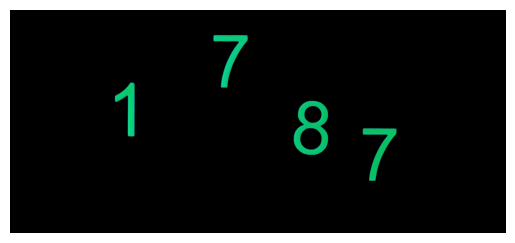

In [ ]:
image_path = '/content/drive/MyDrive/lab4_cosii/dataset_lab3out/1.jpg'
image = cv2.imread(image_path)

if image is None:
    print("Ошибка: изображение не загружено. Проверьте путь к файлу.")
else:
    print("Изображение загружено успешно.")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Отображение изображения
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

Количество найденных контуров: 4


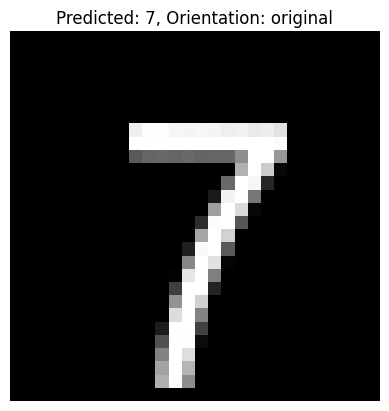

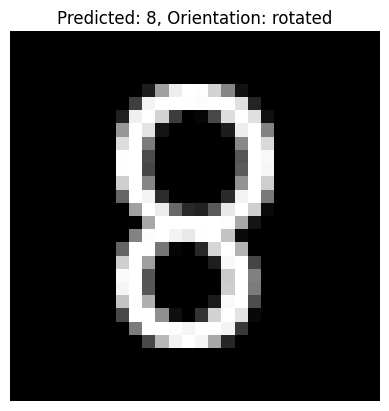

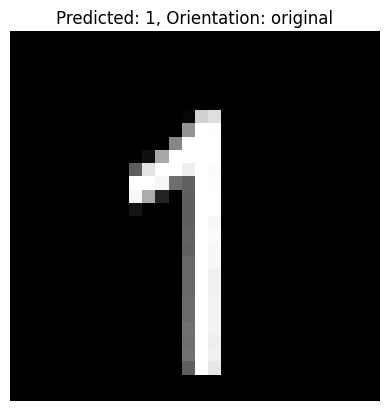

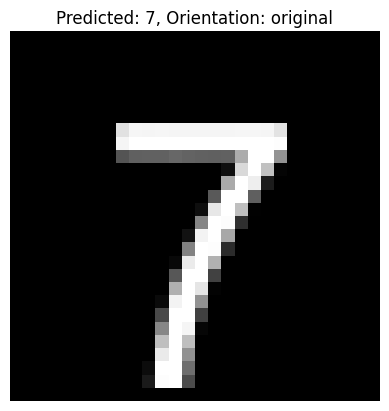

[(7, 0.9999980926513672, 'original'),
 (8, 0.99997878074646, 'rotated'),
 (1, 0.9858629107475281, 'original'),
 (7, 0.9999990463256836, 'original')]

In [ ]:
predicted_digits = predict_label(image)
predicted_digits

Изображение загружено успешно.


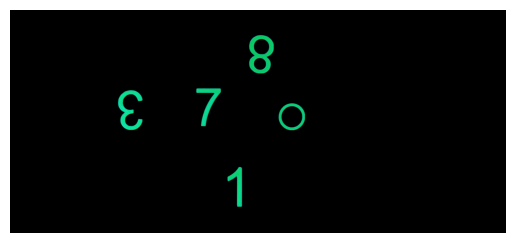

In [ ]:
image_path = '/content/drive/MyDrive/lab4_cosii/dataset_lab3out/7.jpg'
image = cv2.imread(image_path)

if image is None:
    print("Ошибка: изображение не загружено. Проверьте путь к файлу.")
else:
    print("Изображение загружено успешно.")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Отображение изображения
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

Количество найденных контуров: 5


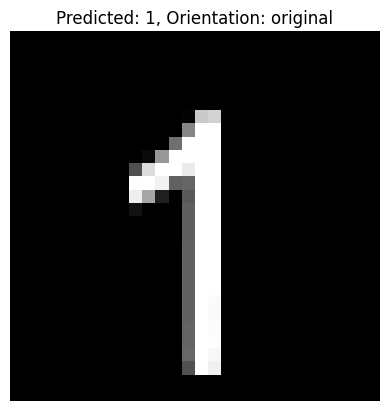

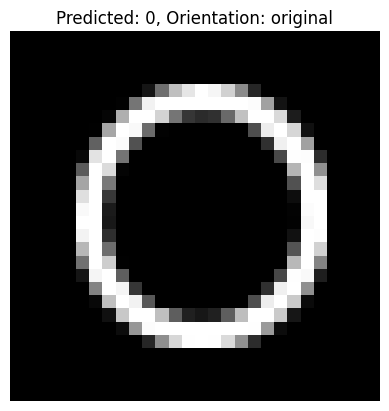

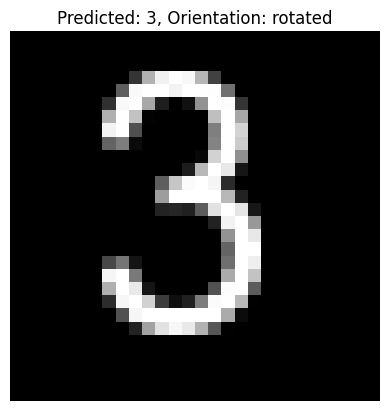

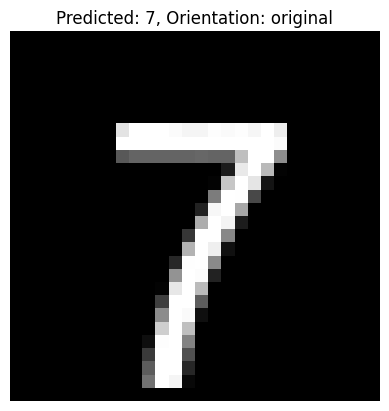

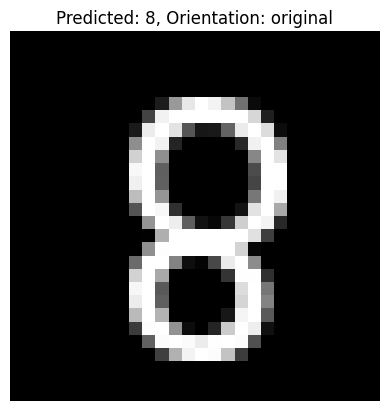

[(1, 0.9835071563720703, 'original'),
 (0, 0.9999788999557495, 'original'),
 (3, 0.999968409538269, 'rotated'),
 (7, 0.9999988079071045, 'original'),
 (8, 0.9999254941940308, 'original')]

In [ ]:
predicted_digits = predict_label(image)
predicted_digits

Изображение загружено успешно.


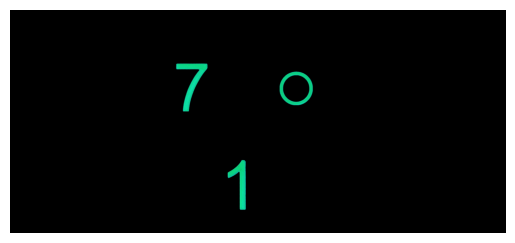

In [ ]:
image_path = '/content/drive/MyDrive/lab4_cosii/dataset_lab3out/10.jpg'
image = cv2.imread(image_path)

if image is None:
    print("Ошибка: изображение не загружено. Проверьте путь к файлу.")
else:
    print("Изображение загружено успешно.")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Отображение изображения
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

Количество найденных контуров: 3


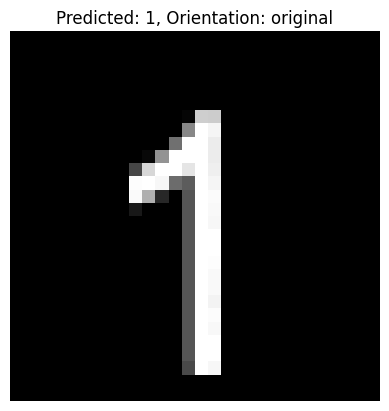

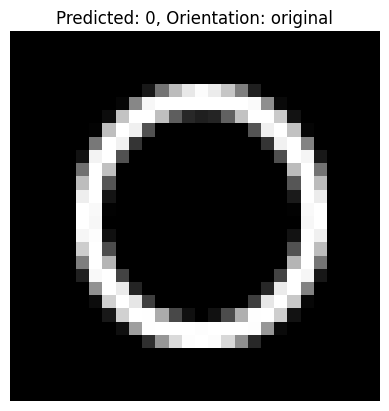

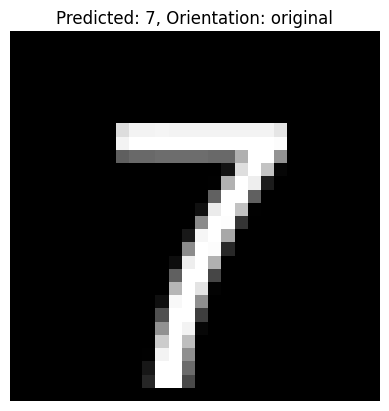

[(1, 0.9808539152145386, 'original'),
 (0, 0.9999752044677734, 'original'),
 (7, 0.9999990463256836, 'original')]

In [ ]:
predicted_digits = predict_label(image)
predicted_digits

Изображение загружено успешно.


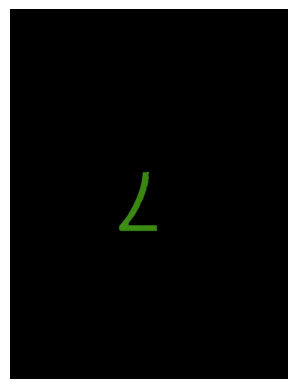

In [ ]:
image_path = '/content/drive/MyDrive/lab4_cosii/dataset_lab3out/11.jpg'
image = cv2.imread(image_path)

if image is None:
    print("Ошибка: изображение не загружено. Проверьте путь к файлу.")
else:
    print("Изображение загружено успешно.")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Отображение изображения
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

Количество найденных контуров: 1


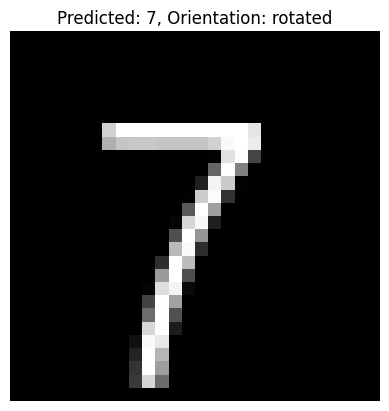

[(7, 0.9999798536300659, 'rotated')]

In [ ]:
predicted_digits = predict_label(image)
predicted_digits